---
tags: [algorithm, chemistry, simulation]
---

# 多次元量子フーリエ変換によるナノシート物質特性推定

量子フーリエ変換（QFT）は、量子アルゴリズムの中核的なプリミティブとして広く使われており、さまざまな応用が提案されています。
しかし従来のQFTに基づく構成では、入力データが2のべき乗のグリッドサイズに自然に定義されない場合に制約がありました。
そこで本記事では、[](https://doi.org/10.1039/D5CP00030K)で提案された、任意のグリッドサイズの入力に対する多次元量子フーリエ変換の実装についてまとめました。
多次元量子フーリエ変換実装を通して、Qamomileの使い方を学ぶことができます。

In [1]:
# Install the latest Qamomile through pip! 
# !pip install qamomile

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import qamomile.circuit as qmc
from qamomile.circuit.algorithm import amplitude_encoding
from qamomile.circuit.stdlib.qft import QFT
from qamomile.circuit.transpiler.job import SampleResult
from qamomile.qiskit import QiskitTranspiler

## 背景

### 問題: ナノシート材料の特性評価

ナノシート材料は、幅広い化学応用のために注目を集めています。
その物理化学的な特性は、その厚さに応じて劇的に変化します。
そのため、ナノシート材料の多様な特性を自在に制御するには、厚さを制御した合成や、ナノシート材料の層数の特定が極めて重要となります。
層数を特定する有望な手段として、透過型電子顕微鏡（TEM）による観測があります。
TEMを用いた観測からは、透過イメージとSelected Area Electron Diffraction（SAED:制限視野電子回折）パターンの両方が得られます。
そこで、計算機によるナノシート材料のSAEDパターンシミュレーションが、有望なアプローチとなっています。

その手法の一つとして、古典的な高速フーリエ変換（FFT）により離散フーリエ変換を計算する方法が活用されてきました。
FFTは非常に高速な手法であり、その計算量は$\mathcal{O} (N \log_2 N)$（$N$:グリッド数）であることが知られています。
しかし、$N = 2^n$ のようにグリッド数が2のべき乗で表されているとすると、$\mathcal{O} (n 2^n)$ となり、指数 $n$ の増大に伴って計算困難になることがわかります。
この有望な解決手法として、近年では量子コンピュータによる量子フーリエ変換（QFT）が脚光を浴びるようになりました。
厳密な標準QFTユニタリは、$n$量子ビット上で$\mathcal{O} (n^2)$ゲートにより実装できます。このことが、QFTを量子フーリエ変換プリミティブとして利用する動機になります。ただし、状態準備と読み出しのコストは別途考慮する必要があります。
そこでこの論文では多次元QFTの応用可能性を探求し、その利用可能な入力データをより詳細に特性評価することを目的として、QFTを用いた$\mathrm{CeO_2}$ナノシートの近似的なSAEDパターンのシミュレーションを行いました。

### 多次元QFT

QFTは、Shorのアルゴリズムや量子位相推定のコア技術としてよく知られています。
QFTに関連する拡張として、[](https://doi.org/10.48550/arXiv.2301.13835)が挙げられます。
この研究では、既知のQFT回路をベースに、多次元QFTを実現する効率的な回路を導出しました。

```{figure} assets/multidimensional_qft_01.png
:width: 100%
:alt: quantum circuit for implementing a d-dimensional Fourier transform from Pfeffer (2023)

[](https://doi.org/10.48550/arXiv.2301.13835)より、$d$次元フーリエ変換を実装するための量子回路図。
```

上図の${\mathrm{initialize}}(\vert v \rangle)$は、入力データに応じて量子状態を準備するサブルーチンを表しています。
状態準備の手法にはいくつかありますが、以降に示す実装では[Möttönen状態準備ルーチンによる振幅エンコーディング](mottonen_amplitude_encoding)を用いています。
しかしこの手法は、各次元サイズが $N_i = 2^{n_i}$ でなければならないという制限がありました。
そこで、[](https://doi.org/10.1039/D5CP00030K)ではこの制限を解消する手法を提案しました。
Qamomileには、1次元QFTが標準で備わっています。
Qamomileの機能を活用することで、多次元QFTも容易に実装することが可能です。

## アルゴリズム: 任意の周期性をもつ多次元入力のためのQFT

結晶やナノシートの実空間構造は、一般に2のべき乗のグリッド上でサンプリングされるとは限りません。
その格子周期性は、任意の整数個のグリッド点に対応しえます。
そこで、[](https://doi.org/10.1039/D5CP00030K)では、結晶の周期性をそのまま量子状態に符号化するための、前処理手法を提案しました。

### 領域の切り捨て/ゼロ埋め

実際に得られる結晶構造のデータは、2のべき乗のグリッド上に定義されているとは限りません。
ある次元方向のサンプリング点数が$2^p$より大きい場合、最初の$2^p$点のみを抜き出すことで、QFTを適用可能にします。
またある次元方向のサンプリング点数が$2^p$より小さい場合、その前後にゼロを追加することでも、QFTを適用可能にします。

### フラットトップ窓関数の適用

領域の切り捨て/ゼロ埋めだけを適用したデータの周波数解析を行うと、本来のスペクトルの横に余分な成分が生じます。
これをサイドローブと呼び、これは領域を切り取ったことで生まれる人工的なスペクトルです。
そこでこれを抑えるために、切り捨て/ゼロ埋めされた入力データ区間の両端を滑らかにゼロに近づける重みづけ関数 (窓関数) を導入しましょう。
この論文では、次のようなフラットトップ関数を用いています。

$$
w_5(n) = \sum_{k=0}^4 (-1)^k a_k \cos \left( \frac{2\pi k n}{N}\right)
$$

ここで$(a_0, a_1, a_2, a_3, a_4) = (0.1881, 0.36923, 0.28702, 0.13077, 0.02488)$であり、$N$は考えている次元方向の点の総数、$n$はその点の位置$(n=0, 1, \dots, N-1)$を表します。
2次元の場合、$w_5(x) w_5(y)$ のような積を、入力に掛け合わせます。

## Qamomileによる実装

Qamomileを用いて、多次元QFTのための量子回路を実装しましょう。

### 入力の作成

入力データを作成しましょう。
ここでは、次のような仮想的な周期データを用いることにします。

In [3]:
Nx = 6
Ny = 6
xs = np.arange(Nx)
ys = np.arange(Ny)
X, Y = np.meshgrid(xs, ys, indexing="ij")
f = np.cos(np.pi * X / 2) * np.cos(np.pi * Y / 2)

作成された入力データは、次のような単純な周期性を持つ2次元データです。

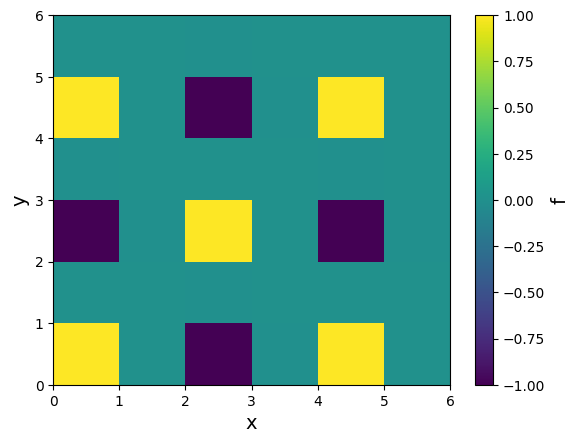

In [4]:
im1 = plt.pcolormesh(f, cmap="viridis")
cbar = plt.colorbar(im1)
cbar.set_label("f", fontsize=14)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.show()

#### ゼロ埋め入力の実装

このデータはサイズが2のべき乗でないために、そのままでは実装されたQFTを適用することができません。
そこでゼロ埋めを施すことで、サイズを2のべき乗に拡張しましょう。
ここでは、$x$方向と$y$方向の座標レジスタそれぞれに3量子ビットを使います。
すなわち、各次元が$2^3 = 8$個のグリッド点を持つようにゼロ埋めします。

In [5]:
def padding_array(array_2d: np.ndarray, num_x_target: int, num_y_target: int) -> np.ndarray:
    num_x, num_y = array_2d.shape    
    pad_width_x = num_x_target - num_x
    pad_width_y = num_y_target - num_y
    pad_x_left = int(np.ceil(pad_width_x / 2.0))
    pad_x_right = int(np.floor(pad_width_x / 2.0))
    pad_y_left = int(np.ceil(pad_width_y / 2.0))
    pad_y_right = int(np.floor(pad_width_y / 2.0))
    array_2d_padding = np.pad(array_2d, ((pad_x_left, pad_x_right), (pad_y_left, pad_y_right)))
    return array_2d_padding

Nqx = 3
Nqy = 3
Nx_target = 2 ** Nqx
Ny_target = 2 ** Nqy
f_padding = padding_array(f, Nx_target, Ny_target)

ゼロ埋めされたデータを見てみましょう。

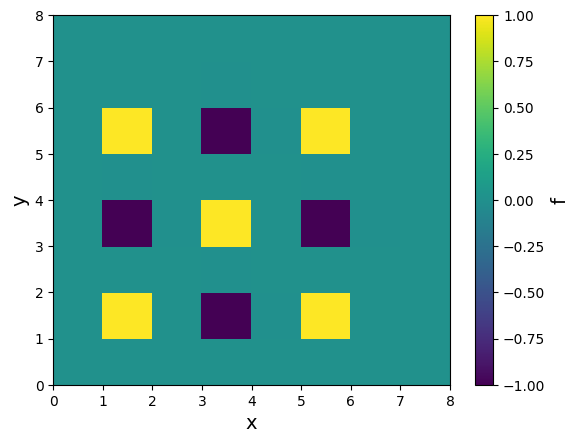

In [6]:
im2 = plt.pcolor(f_padding, cmap="viridis")
cbar = plt.colorbar(im2)
cbar.set_label("f", fontsize=14)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.show()

#### フラットトップ窓関数の実装

続いてはサイドローブを抑えるために、窓関数の実装を行いましょう。

In [7]:
def w5(N: int) -> np.ndarray:
    a = np.array([0.1881, 0.36923, 0.28702, 0.13077, 0.02488])
    n = np.arange(N)
    results = [(-1) ** k * a[k] * np.cos(2 * np.pi * k * n / N) for k in range(5)]
    return sum(results)

wx = w5(Nx_target)
wy = w5(Ny_target)
w2d = wx[:, None] * wy[None, :]

窓関数の概形を描画してみましょう。

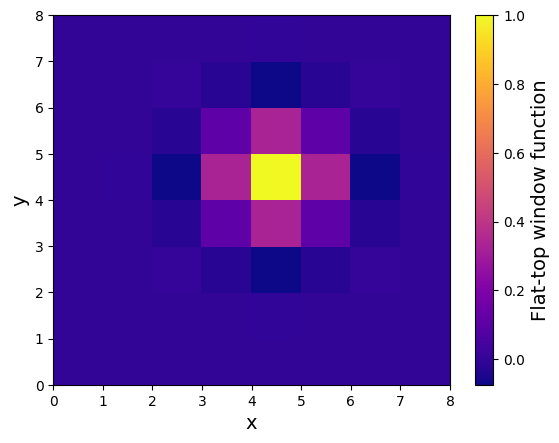

In [8]:
im3 = plt.pcolor(w2d, cmap="plasma")
cbar = plt.colorbar(im3)
cbar.set_label("Flat-top window function", fontsize=14)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.show()

サイドローブを抑えるために、中心領域のみを切り出しつつ、ゆっくりと減衰するような広がった概形になっていることがわかります。
この窓関数をゼロ埋めされたデータに適用し、2次元QFTを実行しましょう。

### 多次元QFT

Qamomileの`QFT`クラスを用いて、多次元QFTを実装しましょう。

In [9]:
@qmc.qkernel
def qft_for_multidimension(inputs: qmc.Vector[qmc.Float]) -> qmc.Vector[qmc.Bit]:
    N = Nqx + Nqy
    q = qmc.qubit_array(N, name="q")
    q = amplitude_encoding(q, inputs)  
    q[0:Nqx] = qmc.qft(q[0:Nqx])
    q[Nqx:N] = qmc.qft(q[Nqx:N])
    return qmc.measure(q)

これでQFTの適用が可能になりました。

### 回路のトランスパイル

先ほど実装したQFT回路をQiskitバックエンド向けにトランスパイルしましょう。
平坦化した入力振幅を、`bindings`を通じてトランスパイル時に指定します。

In [10]:
f_flatten = f_padding.flatten()
transpiler = QiskitTranspiler()
exe = transpiler.transpile(qft_for_multidimension, bindings={"inputs": f_flatten})

## 結果

トランスパイルしたものを実行し、サンプリングされたビット列を2次元の逆格子空間グリッド上の確率にマッピングしましょう。

In [11]:
def compute_prob(result: SampleResult) -> np.ndarray:
    prob = np.zeros(f_padding.shape)
    total = sum(c for _, c in result.results)
    for bits, count in result.results:
        kx = sum(bits[i] << i for i in range(Nqx))
        ky = sum(bits[Nqx + i] << i for i in range(Nqy))
        prob[kx, ky] += count / total
    return prob

result1 = exe.sample(transpiler.executor(), shots=2**14).result()
prob = compute_prob(result1)

### 古典手法との比較: 高速フーリエ変換（FFT）

比較のため、同じ入力に対して古典FFTを適用した場合の結果も計算しましょう。

In [12]:
def compute_classical_fft(f: np.ndarray) -> np.ndarray:
    Nx_target, Ny_target = f.shape
    f_normalized = f / np.linalg.norm(f)
    fft = np.fft.ifft2(f_normalized) * np.sqrt(Nx_target * Ny_target)
    prob = np.abs(fft) ** 2
    return prob

prob_classical = compute_classical_fft(f_padding)

結果を可視化しましょう。

Classical peak value: 0.140625
Quantum peak value: 0.146484375


<Figure size 1400x600 with 0 Axes>

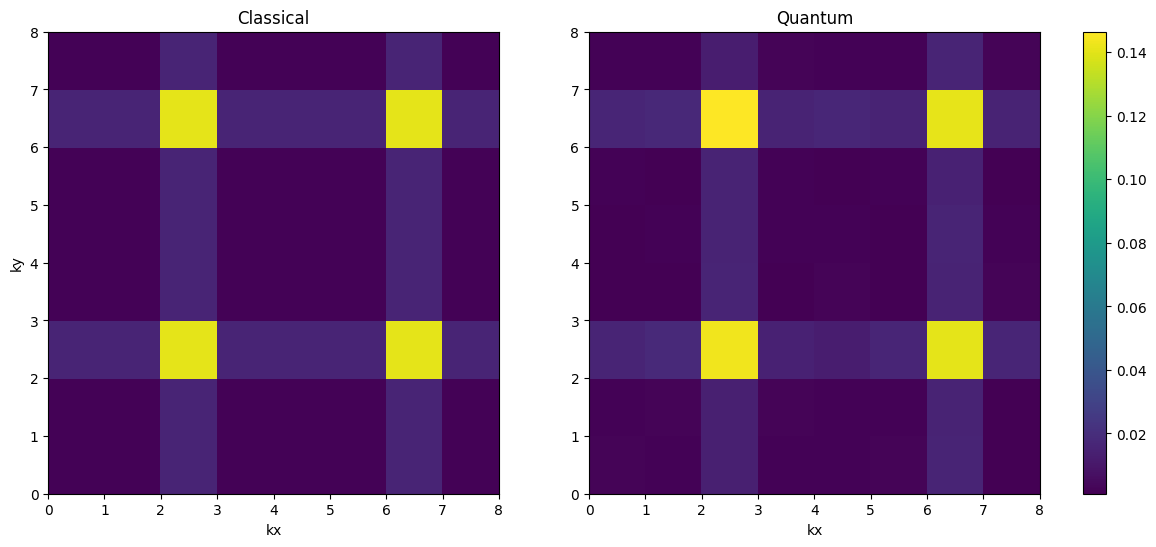

In [13]:
fig = plt.figure(figsize=(14, 6))
vmin = min(prob_classical.min(), prob.min())
vmax = max(prob_classical.max(), prob.max())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im4 = axes[0].pcolor(prob_classical, vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("Classical")
axes[0].set_xlabel("kx")
axes[0].set_ylabel("ky")
im5 = axes[1].pcolor(prob, vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("Quantum")
axes[1].set_xlabel("kx")
print("Classical peak value: {}".format(prob_classical.max()))
print("Quantum peak value: {}".format(prob.max()))
fig.colorbar(im5, ax=axes, fraction=0.046, pad=0.04)
plt.show()

FFT参照結果とQFTサンプリング結果のどちらにも、同様のサイドローブ構造が見られます。

### 窓関数の適用

窓関数を適用した入力を用い、同じ計算を行いましょう。

In [14]:
fw = w2d * f_padding
fw_flatten = fw.flatten()
exe = transpiler.transpile(qft_for_multidimension, bindings={"inputs": fw_flatten})
result2 = exe.sample(transpiler.executor(), shots=2**14).result()
prob2 = compute_prob(result2)

また比較のため、同じく窓関数を適用した入力に古典FFTを適用しましょう。

In [15]:
prob_classical2 = compute_classical_fft(fw)

これら2つの結果を可視化しましょう。

Classical peak value: 0.0604757817215086
Quantum peak value: 0.06439208984375


<Figure size 1400x600 with 0 Axes>

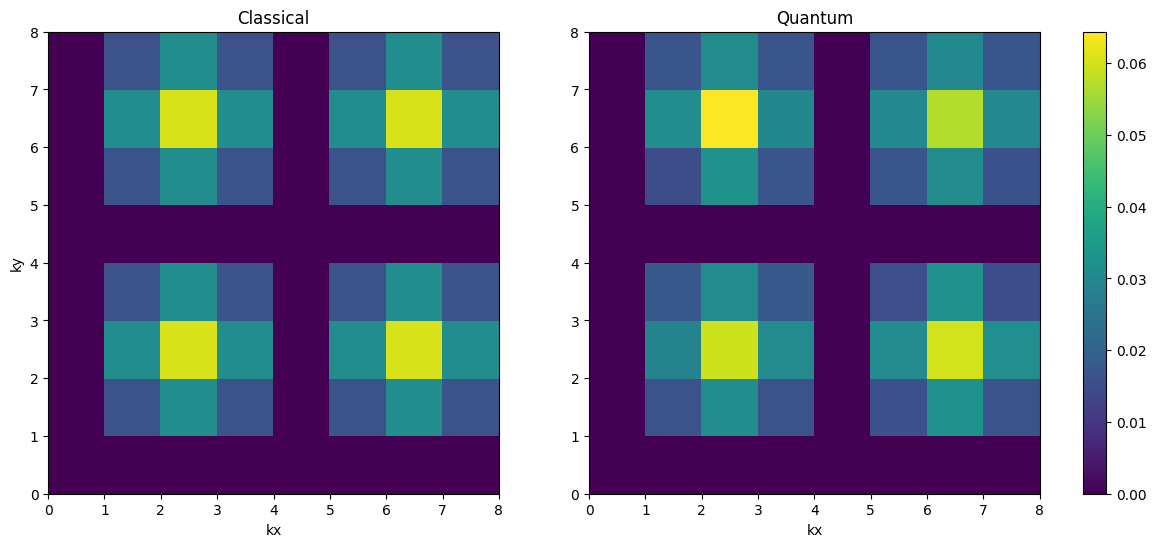

In [16]:
fig = plt.figure(figsize=(14, 6))
vmin = min(prob_classical2.min(), prob2.min())
vmax = max(prob_classical2.max(), prob2.max())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im6 = axes[0].pcolor(prob_classical2, vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("Classical")
axes[0].set_xlabel("kx")
axes[0].set_ylabel("ky")
im7 = axes[1].pcolor(prob2, vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("Quantum")
axes[1].set_xlabel("kx")
print("Classical peak value: {}".format(prob_classical2.max()))
print("Quantum peak value: {}".format(prob2.max()))
fig.colorbar(im7, ax=axes, fraction=0.046, pad=0.04)
plt.show()

窓関数を適用する以前よりピークの値は下がっているものの、サイドローブがより局在化していることがわかります。

## まとめ

ここでは、2のべき乗でない入力データに対する前処理手法を開発した論文と、Qamomileを用いたQFTの実装方法についてご紹介しました。
以下にこのページで紹介した重要な情報をまとめます。

* Qamomileには標準でQFTを実装する機能が備わっています。
* 入力が2のべき乗でない場合、領域を切り捨て/ゼロ埋めすることでQFTを適用可能にします。
* 領域の切り捨て/ゼロ埋めにより生じるスペクトル漏れやサイドローブを、窓関数により抑制します。